# Flower-visit aggregation pipeline

Sweeps every `<date>_system_<sys>` folder in `data/flight_data/`, runs the
flower-visit detector (validated against the reference event
2026-04-13 13:59:32 uids 1002164/1002167 in `flower_visit_detection.ipynb`),
and writes two CSVs into `data/multi_day/`:

| file | level | one row per |
|---|---|---|
| `flower_visits.csv` | per visit | detected flower-visit event |
| `flower_visit_summary.csv` | per (date, system_id) | aggregated foraging-quality indicators |

### Indicators in `flower_visit_summary.csv`

| indicator | definition | literature anchor |
|---|---|---|
| `n_visits` | count of detected visits / day-system | foraging volume |
| `mean_handling_time_s` | mean visit duration (s) | Heinrich 1979, *Bumblebee Economics* |
| `median_handling_time_s` | median visit duration (s) | robust to long-tail outliers |
| `total_visit_time_s` | sum of visit durations | total time on flowers |
| `n_distinct_flowers` | distinct spatial clusters | breadth of foraging |
| `revisit_rate` | `n_visits / n_distinct_flowers` | flower constancy (Klein 2003) |


In [6]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import re

import numpy as np
import pandas as pd

# ── tunables (must match flower_visit_detection.ipynb) ──
HIVE_RADIUS_M    = 0.5
DISP_WINDOW_S    = 1.0
DISP_THR_M       = 0.05
MIN_VISIT_S      = 1.0
LINK_DIST_M      = 0.10
LINK_DT_MAX_S    = 30.0
CLUSTER_RADIUS_M = 0.15

HIVE_XYZ = {900: (-0.040, -0.665, -1.195),
            939: (-0.086, -0.828, -1.045)}

DATA_BASE = Path("../../../data/flight_data")
OUT_DIR   = Path("data/multi_day")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FOLDER_RE = re.compile(r"^(\d{4}-\d{2}-\d{2})_system_(\d+)$")

print(f"Source: {DATA_BASE.resolve()}")
print(f"Output: {OUT_DIR.resolve()}")


Source: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/data/flight_data
Output: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/pats/data/multi_day


## 1. Detector functions


In [ ]:
def per_track_stationary_segments(ft_sub, disp_window_s, disp_thr, min_visit_s):
    """Stationary segments inside one track."""
    if len(ft_sub) < 30: return []
    times = ft_sub["elapsed"].values
    xs = ft_sub["sposX_insect"].values
    ys = ft_sub["sposY_insect"].values
    zs = ft_sub["sposZ_insect"].values
    disp = np.full(len(ft_sub), np.nan)
    j = 0
    for i in range(len(ft_sub)):
        while j < i and times[i] - times[j] >= disp_window_s:
            j += 1
        ref = max(0, j - 1)
        if i - ref >= 5:
            disp[i] = np.sqrt((xs[i]-xs[ref])**2 + (ys[i]-ys[ref])**2 + (zs[i]-zs[ref])**2)
    stat = (disp < disp_thr) & ~np.isnan(disp)

    out, in_run, rs = [], False, 0
    for i, s in enumerate(stat):
        if s and not in_run: rs = i; in_run = True
        elif not s and in_run:
            t0, t1 = times[rs], times[i-1]
            if t1 - t0 >= min_visit_s:
                out.append((t0, t1, xs[rs:i].mean(), ys[rs:i].mean(), zs[rs:i].mean()))
            in_run = False
    if in_run:
        t0, t1 = times[rs], times[-1]
        if t1 - t0 >= min_visit_s:
            out.append((t0, t1, xs[rs:].mean(), ys[rs:].mean(), zs[rs:].mean()))
    return out


def track_endpoints(ft):
    g = ft.sort_values("elapsed").groupby("detection_uid")
    first = g.first(); last = g.last()
    return pd.DataFrame({
        "uid": first.index,
        "t0": first["elapsed"].values, "t1": last["elapsed"].values,
        "x0": first["sposX_insect"].values, "y0": first["sposY_insect"].values, "z0": first["sposZ_insect"].values,
        "x1": last["sposX_insect"].values,  "y1": last["sposY_insect"].values,  "z1": last["sposZ_insect"].values,
        "n_frames": g.size().values,
    }).reset_index(drop=True)


def detect_visits_one_day(ft, hive_xyz):
    """Apply within-track + cross-track detector to one day's flight_tracks."""
    within = []
    for uid, sub in ft.sort_values("elapsed").groupby("detection_uid"):
        for t0, t1, x, y, z in per_track_stationary_segments(
                sub, DISP_WINDOW_S, DISP_THR_M, MIN_VISIT_S):
            within.append({"source": "within", "t_start": t0, "t_end": t1,
                           "x": x, "y": y, "z": z, "duration_s": t1-t0,
                           "uids": [int(uid)]})

    endpoints = track_endpoints(ft).sort_values("t1").reset_index(drop=True)
    cross = []
    for _, a in endpoints.iterrows():
        cand = endpoints[(endpoints["t0"] > a["t1"] + MIN_VISIT_S) &
                          (endpoints["t0"] < a["t1"] + LINK_DT_MAX_S) &
                          (endpoints["uid"] != a["uid"])]
        if cand.empty: continue
        d = np.sqrt((cand["x0"]-a["x1"])**2 + (cand["y0"]-a["y1"])**2 + (cand["z0"]-a["z1"])**2)
        cand = cand.assign(d=d.values)
        cand = cand[cand["d"] < LINK_DIST_M]
        if cand.empty: continue
        b = cand.sort_values("t0").iloc[0]
        cross.append({"source": "cross", "t_start": a["t1"], "t_end": b["t0"],
                      "x": 0.5*(a["x1"]+b["x0"]), "y": 0.5*(a["y1"]+b["y0"]), "z": 0.5*(a["z1"]+b["z0"]),
                      "duration_s": b["t0"]-a["t1"],
                      "uids": [int(a["uid"]), int(b["uid"])]})

    visits = within + cross
    if not visits:
        return pd.DataFrame(columns=["source","t_start","t_end","x","y","z","duration_s","uids","dist_hive_m"])
    df = pd.DataFrame(visits)
    hx, hy, hz = hive_xyz
    df["dist_hive_m"] = np.sqrt((df["x"]-hx)**2 + (df["y"]-hy)**2 + (df["z"]-hz)**2)
    df = df[df["dist_hive_m"] > HIVE_RADIUS_M].reset_index(drop=True)

    # iterative merge of overlapping visits at the same flower
    merge_dist = LINK_DIST_M * 2.0
    changed = True
    while changed:
        changed = False
        df = df.sort_values("t_start").reset_index(drop=True)
        keep = np.ones(len(df), dtype=bool)
        for i in range(len(df)):
            if not keep[i]: continue
            for j in range(i+1, len(df)):
                if not keep[j]: continue
                d = np.sqrt((df.iloc[i]["x"]-df.iloc[j]["x"])**2 +
                            (df.iloc[i]["y"]-df.iloc[j]["y"])**2 +
                            (df.iloc[i]["z"]-df.iloc[j]["z"])**2)
                if d >= merge_dist: continue
                overlap = df.iloc[j]["t_start"] <= df.iloc[i]["t_end"]
                gap     = df.iloc[j]["t_start"] - df.iloc[i]["t_end"]
                if overlap or gap < LINK_DT_MAX_S:
                    df.iat[i, df.columns.get_loc("t_start")] = min(df.iloc[i]["t_start"], df.iloc[j]["t_start"])
                    df.iat[i, df.columns.get_loc("t_end")]   = max(df.iloc[i]["t_end"],   df.iloc[j]["t_end"])
                    df.iat[i, df.columns.get_loc("duration_s")] = df.iloc[i]["t_end"] - df.iloc[i]["t_start"]
                    df.iat[i, df.columns.get_loc("x")] = 0.5 * (df.iloc[i]["x"] + df.iloc[j]["x"])
                    df.iat[i, df.columns.get_loc("y")] = 0.5 * (df.iloc[i]["y"] + df.iloc[j]["y"])
                    df.iat[i, df.columns.get_loc("z")] = 0.5 * (df.iloc[i]["z"] + df.iloc[j]["z"])
                    df.iat[i, df.columns.get_loc("uids")] = sorted(set(df.iloc[i]["uids"] + df.iloc[j]["uids"]))
                    df.iat[i, df.columns.get_loc("source")] = "merged"
                    keep[j] = False
                    changed = True
        df = df[keep].reset_index(drop=True)
    return df


def cluster_into_flowers(visits, radius=CLUSTER_RADIUS_M):
    """Greedy single-link clustering of within-day visit positions."""
    flower_id = np.full(len(visits), -1, dtype=int)
    next_id = 0
    for i in range(len(visits)):
        if flower_id[i] != -1: continue
        flower_id[i] = next_id
        queue = [i]
        while queue:
            k = queue.pop()
            for j in range(len(visits)):
                if flower_id[j] != -1: continue
                d = np.sqrt((visits.iloc[k]["x"]-visits.iloc[j]["x"])**2 +
                            (visits.iloc[k]["y"]-visits.iloc[j]["y"])**2 +
                            (visits.iloc[k]["z"]-visits.iloc[j]["z"])**2)
                if d < radius:
                    flower_id[j] = next_id; queue.append(j)
        next_id += 1
    return flower_id


## 2. Sweep all day-system folders


In [35]:
all_visits_rows = []
summary_rows    = []

folders = sorted(DATA_BASE.glob("*_system_*"))
print(f"Sweeping {len(folders)} folders ...")
for folder in folders:
    m = FOLDER_RE.match(folder.name)
    if not m: continue
    date_str, sys_str = m.groups()
    sid = int(sys_str)
    if sid not in HIVE_XYZ:
        print(f"  skip {folder.name}: unknown system"); continue
    ft_csv = folder / "flight_tracks.csv"
    if not ft_csv.exists():
        print(f"  skip {folder.name}: no flight_tracks.csv"); continue

    ft = pd.read_csv(ft_csv,
                     usecols=["detection_uid", "elapsed",
                              "sposX_insect", "sposY_insect", "sposZ_insect"])

    visits = detect_visits_one_day(ft, HIVE_XYZ[sid])
    if visits.empty:
        summary_rows.append({
            "date": date_str, "system_id": sid,
            "n_visits": 0, "mean_handling_time_s": np.nan,
            "median_handling_time_s": np.nan, "total_visit_time_s": 0.0,
            "n_distinct_flowers": 0, "revisit_rate": np.nan,
        })
        print(f"  {date_str}  sys {sid}: 0 visits"); continue

    flower_id = cluster_into_flowers(visits)
    visits = visits.assign(flower_id=flower_id)

    for _, v in visits.iterrows():
        all_visits_rows.append({
            "date":         date_str,
            "system_id":    sid,
            "t_start_s":    float(v["t_start"]),
            "t_end_s":      float(v["t_end"]),
            "duration_s":   float(v["duration_s"]),
            "x":            float(v["x"]),
            "y":            float(v["y"]),
            "z":            float(v["z"]),
            "dist_hive_m":  float(v["dist_hive_m"]),
            "source":       v["source"],
            "uids":         ";".join(str(u) for u in v["uids"]),
            "flower_id":    int(v["flower_id"]),
        })

    n_visits  = len(visits)
    n_flowers = visits["flower_id"].nunique()
    summary_rows.append({
        "date":                 date_str,
        "system_id":            sid,
        "n_visits":             n_visits,
        "mean_handling_time_s": float(visits["duration_s"].mean()),
        "median_handling_time_s": float(visits["duration_s"].median()),
        "total_visit_time_s":   float(visits["duration_s"].sum()),
        "n_distinct_flowers":   int(n_flowers),
        "revisit_rate":         n_visits / n_flowers if n_flowers else np.nan,
    })
    print(f"  {date_str}  sys {sid}: {n_visits:3d} visits  {n_flowers:2d} flowers  "
          f"mean_dur={visits['duration_s'].mean():5.2f}s")

print(f"\nDone. Total visits detected: {len(all_visits_rows):,}")


Sweeping 48 folders ...
  2026-04-13  sys 900:   5 visits   4 flowers  mean_dur= 2.95s
  2026-04-14  sys 900:  15 visits   9 flowers  mean_dur= 6.62s
  2026-04-15  sys 900:  11 visits   5 flowers  mean_dur= 4.37s
  2026-04-16  sys 900:   7 visits   5 flowers  mean_dur= 4.01s
  2026-04-17  sys 900:  14 visits   7 flowers  mean_dur= 3.56s
  2026-04-18  sys 900:  14 visits   7 flowers  mean_dur= 6.31s
  2026-04-19  sys 900:   9 visits   5 flowers  mean_dur= 9.51s
  2026-04-20  sys 900:  18 visits   8 flowers  mean_dur= 3.32s
  2026-04-21  sys 900:  24 visits   6 flowers  mean_dur= 5.01s
  2026-04-21  sys 939:   3 visits   3 flowers  mean_dur= 3.05s
  2026-04-22  sys 900:  16 visits   6 flowers  mean_dur= 3.58s
  2026-04-22  sys 939:   5 visits   5 flowers  mean_dur= 2.50s
  2026-04-23  sys 900:   6 visits   4 flowers  mean_dur= 5.39s
  2026-04-23  sys 939:   6 visits   6 flowers  mean_dur= 5.52s
  2026-04-24  sys 900:  26 visits   9 flowers  mean_dur= 5.20s
  2026-04-24  sys 939:   5 visi

## 3. Write outputs


In [36]:
visits_df  = pd.DataFrame(all_visits_rows)
summary_df = pd.DataFrame(summary_rows).sort_values(["system_id", "date"]).reset_index(drop=True)

visits_df.to_csv(OUT_DIR / "flower_visits.csv", index=False)
summary_df.to_csv(OUT_DIR / "flower_visit_summary.csv", index=False)

print(f"Wrote:")
print(f"  {OUT_DIR/'flower_visits.csv'}        ({len(visits_df):,} visits)")
print(f"  {OUT_DIR/'flower_visit_summary.csv'} ({len(summary_df):,} day-system rows)")
print()
print("Summary preview:")
print(summary_df.to_string(index=False))

# --- 4. PRETTY PRINT UIDS FOR VIDEO VALIDATION ---
print("\n--- DETAILED VISIT LIST ---")
print(f"{'flower':>7s}  {'t_start_s':>9s}  {'dur_s':>5s}  {'source':>7s}  "
        f"{'x':>7s}  {'y':>7s}  {'z':>7s}  {'d_hive':>7s}  uids")

# Sort chronologically and print formatted rows
for _, r in sub_df.sort_values("t_start_s").iterrows():
    print(f"  {int(r['flower_id']):7d}  {r['t_start_s']:9.1f}  {r['duration_s']:5.2f}  "
            f"{r['source']:>7s}  {r['x']:7.3f}  {r['y']:7.3f}  {r['z']:7.3f}  "
            f"{r['dist_hive_m']:7.3f}  {r['uids']}")

Wrote:
  data/multi_day/flower_visits.csv        (462 visits)
  data/multi_day/flower_visit_summary.csv (48 day-system rows)

Summary preview:
      date  system_id  n_visits  mean_handling_time_s  median_handling_time_s  total_visit_time_s  n_distinct_flowers  revisit_rate
2026-04-13        900         5              2.953359                1.424378           14.766795                   4      1.250000
2026-04-14        900        15              6.622422                4.673809           99.336328                   9      1.666667
2026-04-15        900        11              4.367338                1.858320           48.040713                   5      2.200000
2026-04-16        900         7              4.006305                5.330261           28.044137                   5      1.400000
2026-04-17        900        14              3.558546                1.507832           49.819651                   7      2.000000
2026-04-18        900        14              6.307154            

## 4. Quick condition comparison

Boxplots for `mean_handling_time_s`, `n_distinct_flowers`, `n_visits` across
BASELINE / OFF / ON per system — shared y-axis per indicator.


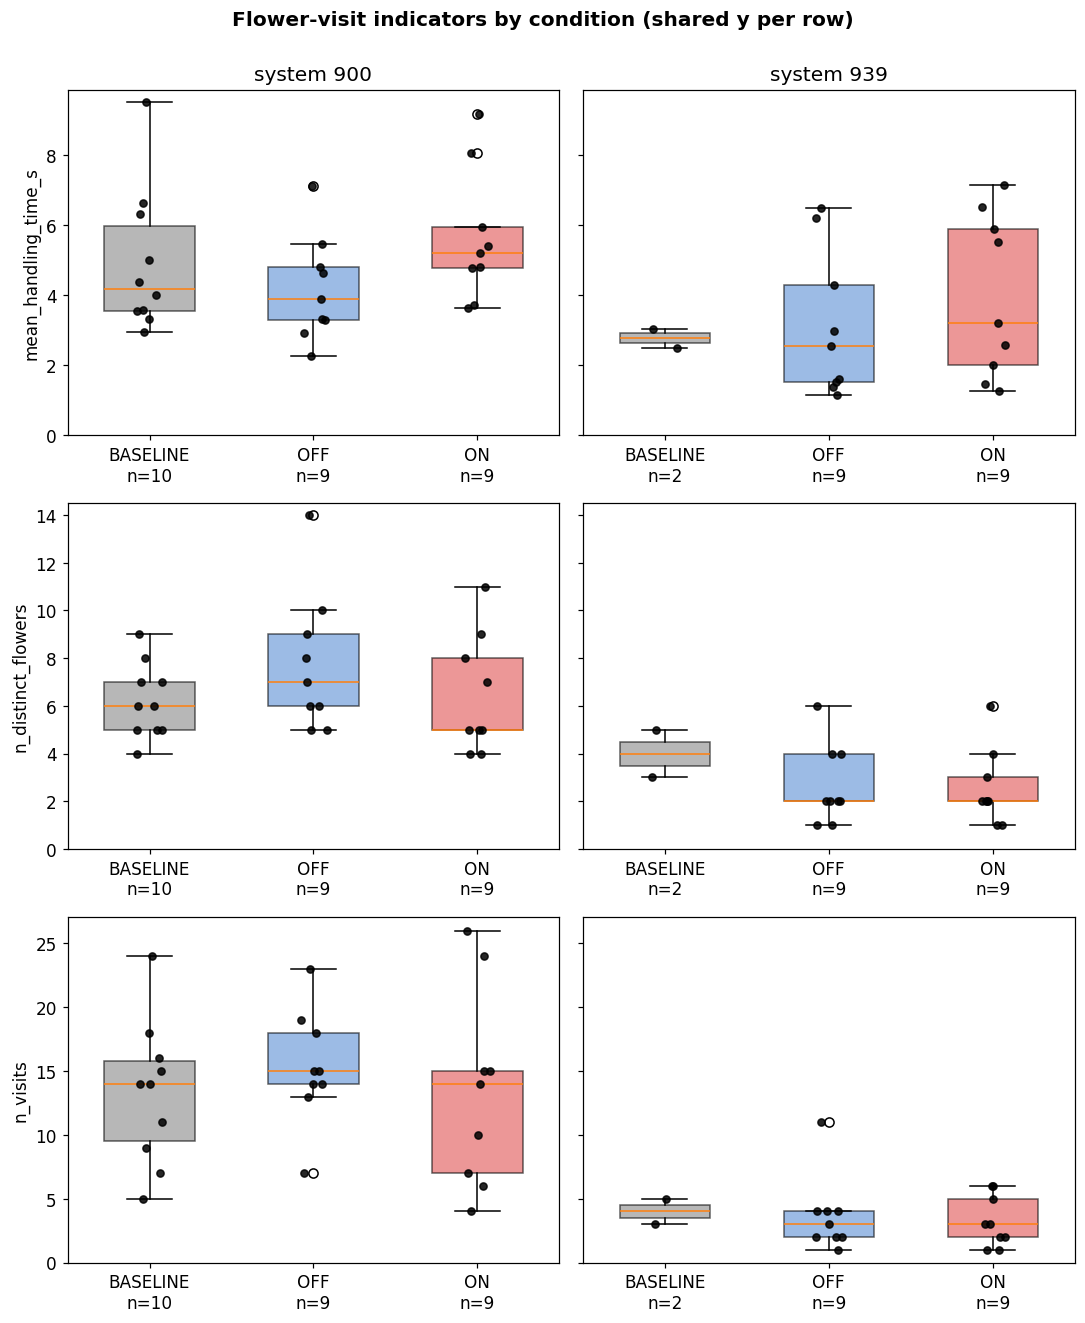

Direction per (system, indicator) - median across conditions:
sys 900:
  mean_handling_time_s          BASELINE=4.19  OFF=3.91  ON=5.20
  n_distinct_flowers            BASELINE=6.00  OFF=7.00  ON=5.00
  n_visits                      BASELINE=14.00  OFF=15.00  ON=14.00
sys 939:
  mean_handling_time_s          BASELINE=2.78  OFF=2.55  ON=3.21
  n_distinct_flowers            BASELINE=4.00  OFF=2.00  ON=2.00
  n_visits                      BASELINE=4.00  OFF=3.00  ON=3.00


In [37]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

CYCLE_ANCHOR = pd.Timestamp("2026-04-23")
def label_date(d):
    d = pd.Timestamp(d)
    if d < CYCLE_ANCHOR: return "BASELINE"
    return "ON" if ((d - CYCLE_ANCHOR).days // 3) % 2 == 0 else "OFF"

summary_df["date_ts"]  = pd.to_datetime(summary_df["date"])
summary_df["condition"] = summary_df["date_ts"].apply(label_date)

INDICATORS = ["mean_handling_time_s", "n_distinct_flowers", "n_visits"]
ORDER = ["BASELINE", "OFF", "ON"]
COND_COLOUR = {"BASELINE": "#888888", "OFF": "#5B8FD4", "ON": "#E05252"}

systems = sorted(summary_df["system_id"].unique())
fig, axes = plt.subplots(len(INDICATORS), len(systems),
                         figsize=(5 * len(systems), 4 * len(INDICATORS)),
                         sharey="row", squeeze=False)
for row, ind in enumerate(INDICATORS):
    for col, sid in enumerate(systems):
        ax = axes[row][col]
        data, labels, colors = [], [], []
        for cond in ORDER:
            vals = summary_df.loc[(summary_df["system_id"] == sid) &
                                   (summary_df["condition"] == cond), ind].dropna()
            data.append(vals); labels.append(f"{cond}\nn={len(vals)}"); colors.append(COND_COLOUR[cond])
        bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55)
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        for i, vals in enumerate(data):
            ax.scatter(np.full(len(vals), i+1) + np.random.uniform(-0.08, 0.08, len(vals)),
                       vals, color="black", s=22, alpha=0.85, zorder=3)
        if row == 0: ax.set_title(f"system {sid}")
        if col == 0: ax.set_ylabel(ind)
        ax.set_ylim(bottom=0)
fig.suptitle("Flower-visit indicators by condition (shared y per row)",
             fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

print("Direction per (system, indicator) - median across conditions:")
for sid in systems:
    print(f"sys {sid}:")
    for ind in INDICATORS:
        meds = summary_df[summary_df["system_id"] == sid].groupby("condition")[ind].median()
        meds = meds.reindex(ORDER)
        parts = [f"{cond}={v:.2f}" for cond, v in meds.items() if pd.notna(v)]
        print(f"  {ind:<28s}  " + "  ".join(parts))


## 3D plot

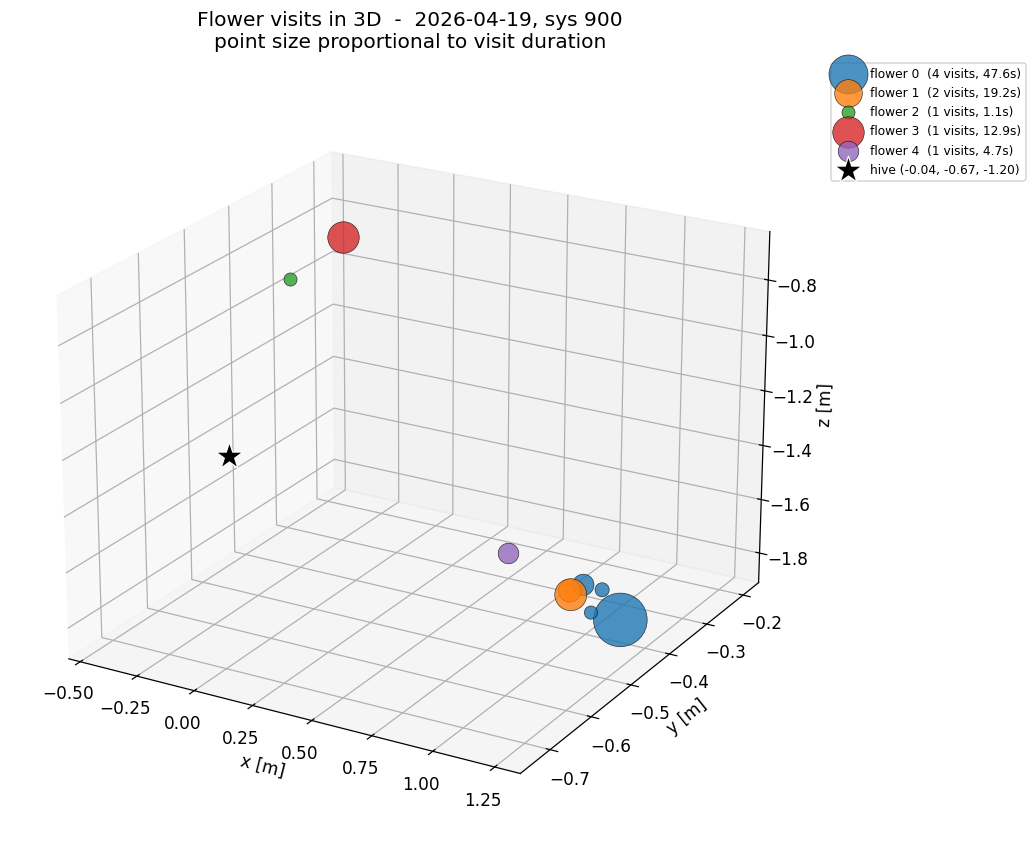

In [38]:
from mpl_toolkits.mplot3d import Axes3D

# --- Choose which day and system to inspect ---
DAY = "2026-04-19" # Change this to check different days
SYS = 900

# Filter the generated visits_df for this specific day/sys
sub_df = visits_df[(visits_df["date"] == DAY) & (visits_df["system_id"] == SYS)]

if sub_df.empty:
    print(f"No visits found for {DAY} on system {SYS}.")
else:
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Plot each flower cluster with a distinct colour, size scaled by visit duration
    cmap = plt.get_cmap("tab10")
    for fid, sub in sub_df.groupby("flower_id"):
        ax.scatter(sub["x"], sub["y"], sub["z"],
                   s=40 + 30 * sub["duration_s"],
                   color=cmap(fid % 10),
                   alpha=0.8,
                   edgecolor="black",
                   linewidth=0.4,
                   label=f"flower {fid}  ({len(sub)} visits, {sub['duration_s'].sum():.1f}s)")

    # Hive marker (using the dictionary already in your notebook)
    hx, hy, hz = HIVE_XYZ[SYS]
    ax.scatter([hx], [hy], [hz],
               marker="*", s=350, c="black", edgecolor="white", linewidth=0.8,
               label=f"hive ({hx:.2f}, {hy:.2f}, {hz:.2f})")

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(f"Flower visits in 3D  -  {DAY}, sys {SYS}\n"
                 f"point size proportional to visit duration")
    
    # Only show legend if there aren't too many flowers (prevents UI clutter)
    if sub_df["flower_id"].nunique() <= 15:
        ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))

    # Set viewing angle - greenhouse layout reads best with a slight tilt
    ax.view_init(elev=22, azim=-60)

    plt.tight_layout()
    plt.show()

### XY and YZ -axis plots

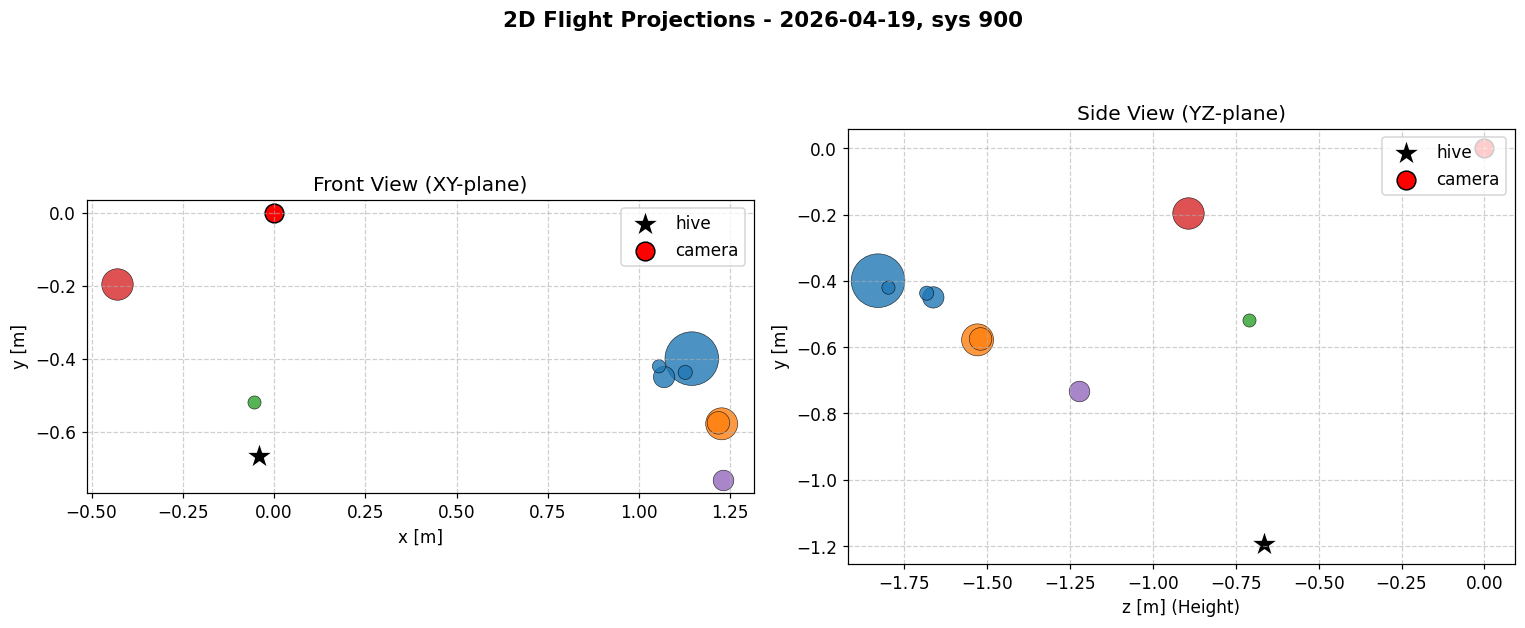

In [39]:
# Create a side-by-side figure for the 2D projections
fig, (ax_xy, ax_yz) = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.get_cmap("tab10")

hx, hy, hz = HIVE_XYZ[SYS]

# --- Subplot 1: Front View (XY) ---
for fid, sub in sub_df.groupby("flower_id"):
    ax_xy.scatter(sub["x"], sub["y"], 
                  s=40 + 30 * sub["duration_s"], color=cmap(fid % 10), 
                  alpha=0.8, edgecolor="black", linewidth=0.4)

ax_xy.scatter([hx], [hy], marker="*", s=350, c="black", edgecolor="white", label="hive")
ax_xy.scatter([0], [0], marker="o", s=150, c="red", edgecolor="black", label="camera")

ax_xy.set_xlabel("x [m]")
ax_xy.set_ylabel("y [m]")
ax_xy.set_title("Front View (XY-plane)")
ax_xy.grid(True, linestyle="--", alpha=0.6)
ax_xy.legend(loc="upper right")
ax_xy.set_aspect('equal', adjustable='box') # Keeps distance scale accurate

# --- Subplot 2: Side View (YZ) ---
for fid, sub in sub_df.groupby("flower_id"):
    ax_yz.scatter(sub["z"], sub["y"], 
                  s=40 + 30 * sub["duration_s"], color=cmap(fid % 10), 
                  alpha=0.8, edgecolor="black", linewidth=0.4)

ax_yz.scatter([hy], [hz], marker="*", s=350, c="black", edgecolor="white", label="hive")
ax_yz.scatter([0], [0], marker="o", s=150, c="red", edgecolor="black", label="camera")

ax_yz.set_xlabel("z [m] (Height)")
ax_yz.set_ylabel("y [m]")
ax_yz.set_title("Side View (YZ-plane)")
ax_yz.grid(True, linestyle="--", alpha=0.6)
ax_yz.legend(loc="upper right")
ax_yz.set_aspect('equal', adjustable='box') # Keeps height scale accurate

fig.suptitle(f"2D Flight Projections - {DAY}, sys {SYS}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# --- Extract UIDs for a specific flower ---
TARGET_FLOWER_ID = 2  # Change this to the ID of the green flower from your legend

print(f"\n--- UIDS FOR GREEN FLOWER (ID: {TARGET_FLOWER_ID}) ---")
green_visits = sub_df[sub_df["flower_id"] == TARGET_FLOWER_ID]

if green_visits.empty:
    print("No visits found for this flower ID.")
else:
    for _, r in green_visits.sort_values("t_start_s").iterrows():
        print(f"Time: {r['t_start_s']:7.1f}s | Dur: {r['duration_s']:5.2f}s | UIDs: {r['uids']}")


--- UIDS FOR GREEN FLOWER (ID: 2) ---
Time:  1367.4s | Dur: 39.78s | UIDs: 1328785;1328800;1328834;1328848;1337429
Time:  1530.8s | Dur:  5.17s | UIDs: 1331699;1331707
Time:  1927.1s | Dur:  1.16s | UIDs: 1334367
Time:  2657.7s | Dur:  8.07s | UIDs: 1329932;1326238
Time:  3024.2s | Dur:  1.52s | UIDs: 1326572;1326576


## 5. Plug into `5g_foraging_effect_model.ipynb`

In the indicator-table cell, join the summary CSV and replace
`median_ifi_s` + `vertical_deviation` with the new indicators:

```python
fv = pd.read_csv("data/multi_day/flower_visit_summary.csv")
fv["date"] = pd.to_datetime(fv["date"])
ind = ind.merge(fv[["date","system_id","mean_handling_time_s","n_distinct_flowers"]],
                on=["date","system_id"], how="left")

INDICATORS = [
    "neg_exit_count",
    "neg_re_ratio",
    "path_tortuosity",
    "ifi_cv",
    "mean_handling_time_s",   # NEW - Heinrich 1979 efficiency metric
    "n_distinct_flowers",     # NEW - flower-constancy proxy
]
```

Indicator count stays at 6; the verdict pipeline downstream is unchanged.
